In [5]:
import gzip
import pickle

with gzip.open("CMI_timeseries_dataset.pkl.gz", "rb") as f:
    CMI_timeseries_dataset = pickle.load(f)

In [6]:
# Nombre de séries temporales
print(len(CMI_timeseries_dataset))

# Voir la première série
print(CMI_timeseries_dataset[0].head())

# Sa forme (lignes x colonnes)
print(CMI_timeseries_dataset[0].shape)

# Les colonnes disponibles
print(CMI_timeseries_dataset[0].columns.tolist())

4437
          X         Y         Z      enmo     anglez  non-wear_flag  \
0 -0.696639 -0.058477 -0.086717  0.051424  -6.090168            0.0   
1 -0.479150  0.218840 -0.289497  0.062909 -19.893288            0.0   
2 -0.440287 -0.171177 -0.326227  0.121546 -23.043303            0.0   
3 -0.559035 -0.293204 -0.145227  0.084953  -9.694811            0.0   
4 -0.531364 -0.210126 -0.086370  0.074157  -6.412807            0.0   

       light  battery_voltage  weekday  quarter  relative_date_PCIAT    id  \
0  21.794674      4023.000000      4.0      4.0                253.0  2265   
1  20.835835      4023.000000      4.0      4.0                253.0  2265   
2   6.294650      4023.000000      4.0      4.0                253.0  2265   
3   0.462963      4022.616699      4.0      4.0                253.0  2265   
4   4.058062      4020.583252      4.0      4.0                253.0  2265   

   sii_binary  
0           0  
1           0  
2           0  
3           0  
4           0  
(20

In [7]:
import pandas as pd

# 1. Distribution des classes
labels = [df["sii_binary"].iloc[0] for df in CMI_timeseries_dataset]
print(pd.Series(labels).value_counts())
print(pd.Series(labels).value_counts(normalize=True) * 100)

# 2. Combien de sujets uniques ?
users = [df["id"].iloc[0] for df in CMI_timeseries_dataset]
print(f"Sujets uniques : {len(set(users))}")

# 3. Valeurs manquantes sur la première série
print(CMI_timeseries_dataset[0].isnull().sum())

0    2957
1    1480
Name: count, dtype: int64
0    66.644129
1    33.355871
Name: proportion, dtype: float64
Sujets uniques : 494
X                      0
Y                      0
Z                      0
enmo                   0
anglez                 0
non-wear_flag          0
light                  0
battery_voltage        0
weekday                0
quarter                0
relative_date_PCIAT    0
id                     0
sii_binary             0
dtype: int64


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
signal_cols = ["X", "Y", "Z", "enmo", "anglez", "light", "battery_voltage"]

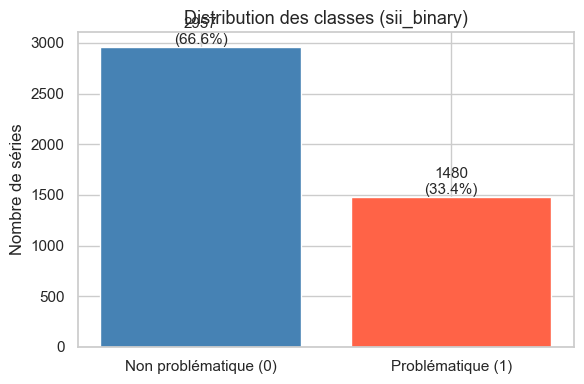

In [10]:
labels = [df["sii_binary"].iloc[0] for df in CMI_timeseries_dataset]
counts = pd.Series(labels).value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Non problématique (0)", "Problématique (1)"],
              counts.values,
              color=["steelblue", "tomato"])

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{val}\n({val/sum(counts.values)*100:.1f}%)",
            ha="center", fontsize=11)

ax.set_title("Distribution des classes (sii_binary)", fontsize=13)
ax.set_ylabel("Nombre de séries")
plt.tight_layout()
plt.show()

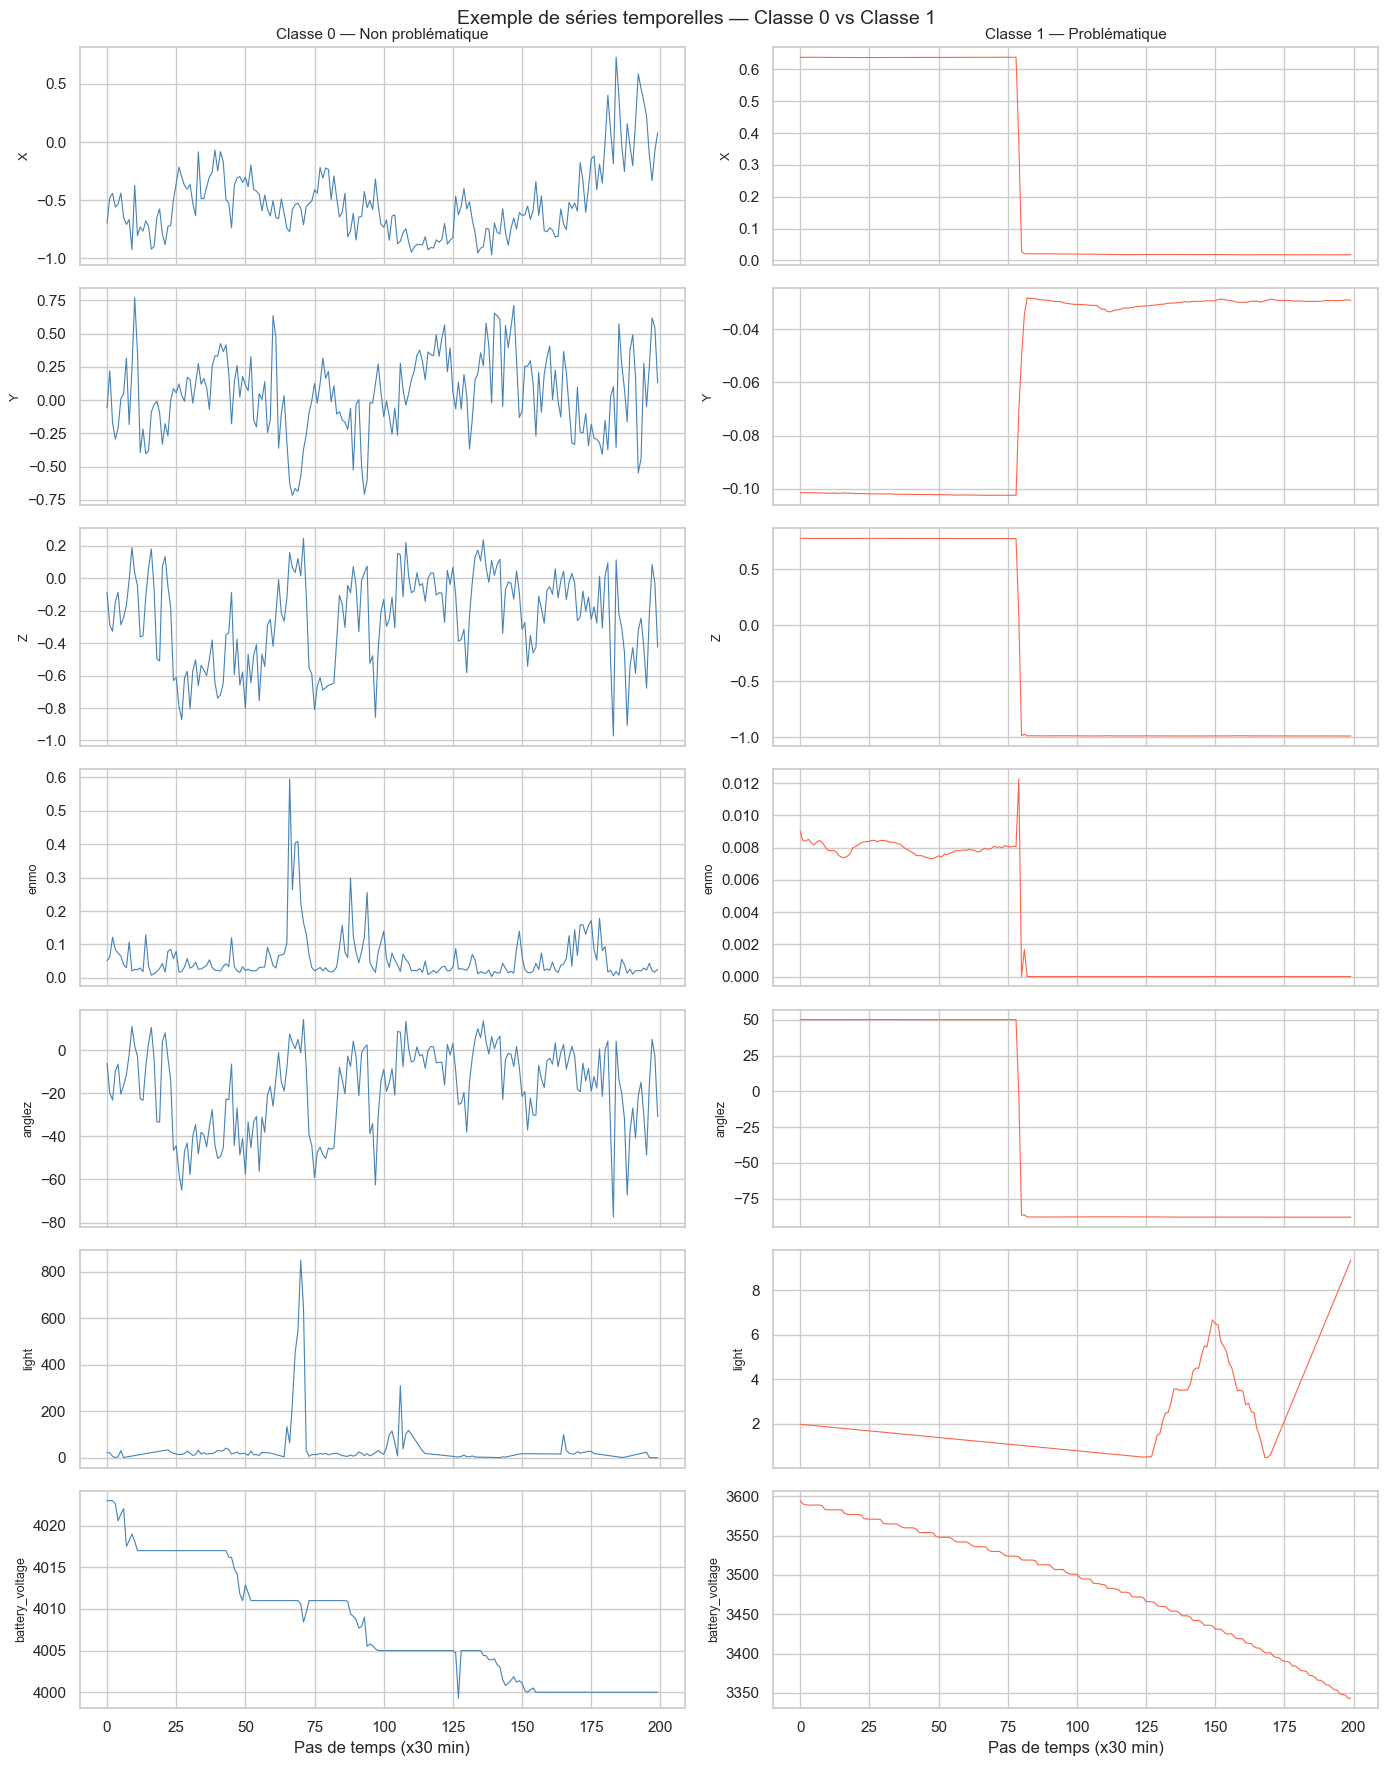

In [11]:
# Prendre un exemple de chaque classe
idx_0 = next(i for i, df in enumerate(CMI_timeseries_dataset) if df["sii_binary"].iloc[0] == 0)
idx_1 = next(i for i, df in enumerate(CMI_timeseries_dataset) if df["sii_binary"].iloc[0] == 1)

fig, axes = plt.subplots(len(signal_cols), 2, figsize=(14, 18), sharex=True)
fig.suptitle("Exemple de séries temporelles — Classe 0 vs Classe 1", fontsize=14)

for row, col in enumerate(signal_cols):
    for class_idx, (idx, color, label) in enumerate([
        (idx_0, "steelblue", "Classe 0 — Non problématique"),
        (idx_1, "tomato",    "Classe 1 — Problématique")
    ]):
        ax = axes[row][class_idx]
        ax.plot(CMI_timeseries_dataset[idx][col].values, color=color, linewidth=0.8)
        ax.set_ylabel(col, fontsize=9)
        if row == 0:
            ax.set_title(label, fontsize=11)
        if row == len(signal_cols) - 1:
            ax.set_xlabel("Pas de temps (x30 min)")

plt.tight_layout()
plt.show()

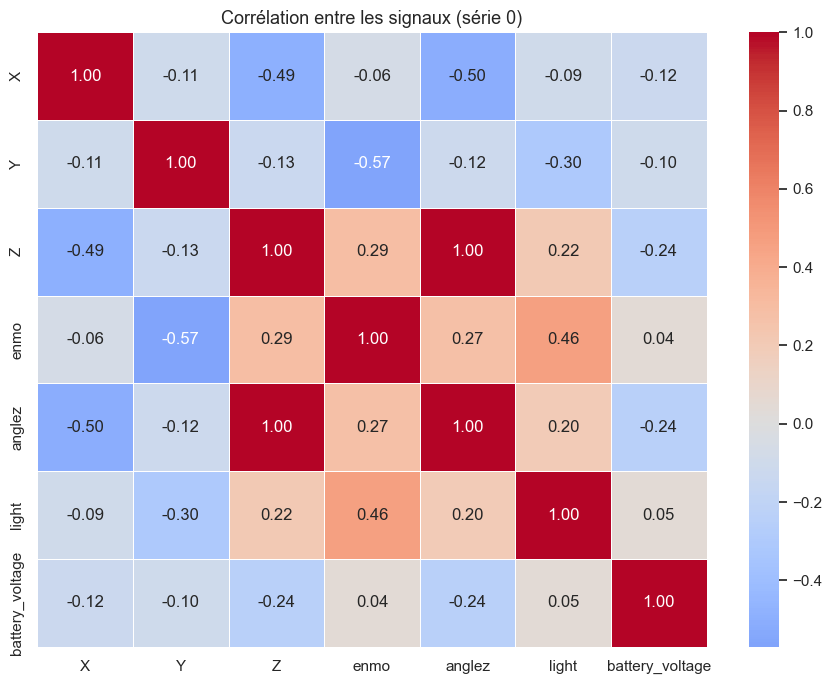

In [13]:
# Prendre toutes les valeurs de la première série comme exemple
sample = CMI_timeseries_dataset[0][signal_cols]

corr = sample.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Corrélation entre les signaux (série 0)", fontsize=13)
plt.tight_layout()
plt.show()

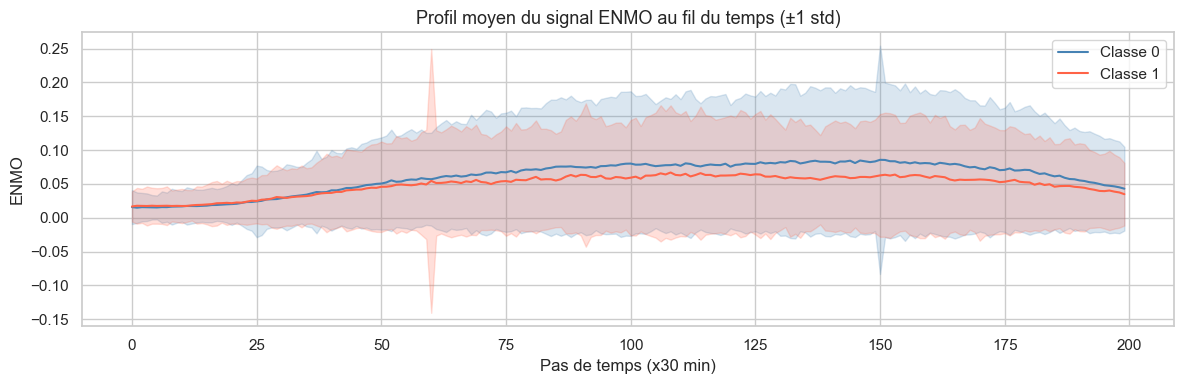

In [14]:
# Moyenne du signal "enmo" à chaque timestep, par classe
enmo_0 = np.array([df["enmo"].values for df in CMI_timeseries_dataset
                   if df["sii_binary"].iloc[0] == 0])
enmo_1 = np.array([df["enmo"].values for df in CMI_timeseries_dataset
                   if df["sii_binary"].iloc[0] == 1])

fig, ax = plt.subplots(figsize=(12, 4))
t = np.arange(200)

ax.plot(t, enmo_0.mean(axis=0), color="steelblue", label="Classe 0", linewidth=1.5)
ax.fill_between(t,
                enmo_0.mean(axis=0) - enmo_0.std(axis=0),
                enmo_0.mean(axis=0) + enmo_0.std(axis=0),
                alpha=0.2, color="steelblue")

ax.plot(t, enmo_1.mean(axis=0), color="tomato", label="Classe 1", linewidth=1.5)
ax.fill_between(t,
                enmo_1.mean(axis=0) - enmo_1.std(axis=0),
                enmo_1.mean(axis=0) + enmo_1.std(axis=0),
                alpha=0.2, color="tomato")

ax.set_title("Profil moyen du signal ENMO au fil du temps (±1 std)", fontsize=13)
ax.set_xlabel("Pas de temps (x30 min)")
ax.set_ylabel("ENMO")
ax.legend()
plt.tight_layout()
plt.show()